# ESM1.6 Scaling

End-to-end pipeline generating scaling plots for the [ESM1.6 piControl configuration v2.0](https://github.com/ACCESS-NRI/access-esm1.6-configs/releases/tag/release-piControl-2.0).

In [1]:
%load_ext autoreload
%autoreload 2

# Record package versions for future reference
from importlib.metadata import version
for pkg in ("access.config.utils", "access.profiling", "payu", "experiment_generator", "experiment_runner"):
    print(f"{pkg}: {version(pkg)}")

access.config.utils: 0.5.dev3+g45c8354dc
access.profiling: 0.2.dev39+g4e244fb8b
payu: 1.3.6
experiment_generator: 0.10.3.dev1+g93564c8e5
experiment_runner: 0.3.2


## Setup
The following variables control where the configurations and model run outputs are saved.

In [2]:
## Imports
from pathlib import Path

from access.profiling import ESM16Profiling

work_path = f"/scratch/tm70/model_scaling/ACCESS-ESM1.6/piControl-2.0"
archive_path = f"/g/data/tm70/model_scaling/ACCESS-ESM1.6/piControl-2.0/archive"

esm_profiling = ESM16Profiling(work_dir=Path(work_path), archive_dir=Path(archive_path))
esm_profiling.set_control(repository="https://github.com/ACCESS-NRI/access-esm1.6-configs.git", commit="release-piControl-2.0")

## Generate experiments

We will perform a simple scaling study, varying the total number of nodes used over `[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0]`. We will search for different layouts that closely match a scaled 4-node released piControl config.

In [3]:
from access.config.parallel_allocation_strategies import RootAllocation, FreeAllocation
from access.config.parallel_constraints import SubdomainAspectRatioConstraint, RankRatioGroupConstraint, MaxWastedCoreFractionConstraint

num_nodes_list = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0]
cores_per_node = 104

# Define how the cores should be allocated to the components:
#   - UM7 uses at least as many cores as MOM5.
#   - MOM5 uses at least 90% of the number of cores assigned to UM7.
#   - Assign between 3 and 16 cores to CICE5.
#   - Reject layouts that waste more than 1% of the available cores.
#   - Require MOM5 and UM7 domains to have an aspect ratio between the x and y axis not larger than 1.25 to reduce internal load-inbalance.
allocation_strategy = RootAllocation(
    subcomponents={
        "UM7": FreeAllocation(
            local_constraints=(SubdomainAspectRatioConstraint(max_ratio=1.25),),
        ),
        "MOM5": FreeAllocation(
            local_constraints=(SubdomainAspectRatioConstraint(max_ratio=1.25),),
        ),
        "CICE5": FreeAllocation(min_cores=3, max_cores=16)
    },
    local_constraints=(MaxWastedCoreFractionConstraint(max_fraction=0.01),),
    group_constraints=(
        RankRatioGroupConstraint(name_a="MOM5", name_b="UM7", min_ratio=0.9),
        RankRatioGroupConstraint(name_a="UM7", name_b="MOM5", min_ratio=1.0),
    ),
)

# Write how many layouts are going to be generated for each number of nodes
from access.config.parallel_layouts import iter_layouts
from access.profiling.access_models import ESM16_COMPONENT
for num_nodes in num_nodes_list:
    layouts = list(iter_layouts(ESM16_COMPONENT, int(num_nodes*cores_per_node), allocations=allocation_strategy))
    print(f"Num nodes: {num_nodes}, Num layouts: {len(layouts)}")

Num nodes: 1.0, Num layouts: 1
Num nodes: 2.0, Num layouts: 1
Num nodes: 3.0, Num layouts: 12
Num nodes: 4.0, Num layouts: 16
Num nodes: 5.0, Num layouts: 18
Num nodes: 6.0, Num layouts: 29
Num nodes: 8.0, Num layouts: 47


In [4]:
# Generate the configuration and write to file
control_options = {
            "config.yaml": {
                "modules": {
                    "use": ["/g/data/vk83/prerelease/modules"],
                    "load": ["access-esm1p6/pr221-2"],
                },
                "manifest": {"reproduce": {"exe": False}},
                "postscript": "REMOVE",
            }
}

def walltime(num_nodes):
    return 2.5 * 4.0/num_nodes # use a 2.5 hrs time for 4-node runs, and then scale linearly

esm_profiling.generate_scaling_experiments(num_nodes_list=num_nodes_list, control_options=control_options, cores_per_node=cores_per_node, walltime=walltime, allocations=allocation_strategy)

No new experiments to generate. Will skip generation.


## Run experiments

Next we run the experiments

In [5]:
esm_profiling.run_experiments()

## Parsing and plotting experiment results

In [6]:
# Parse the data
esm_profiling.parse_profiling_data()

In [7]:
from access.profiling.metrics import tmax

# Get the best (fastest) layouts for each node count
best_experiments = esm_profiling.select_best_experiments(component="payu",region="payu_model_run_duration_seconds", metric=tmax)
best_experiments

['esm1p6-layout_atm_8x6_mom_8x6_ice_8x1',
 'esm1p6-layout_atm_12x8_mom_12x8_ice_15x1',
 'esm1p6-layout_atm_14x11_mom_15x10_ice_8x1',
 'esm1p6-layout_atm_16x13_mom_17x12_ice_4x1',
 'esm1p6-layout_atm_20x13_mom_18x14_ice_8x1',
 'esm1p6-layout_atm_20x16_mom_21x14_ice_10x1',
 'esm1p6-layout_atm_24x17_mom_24x17_ice_10x1']

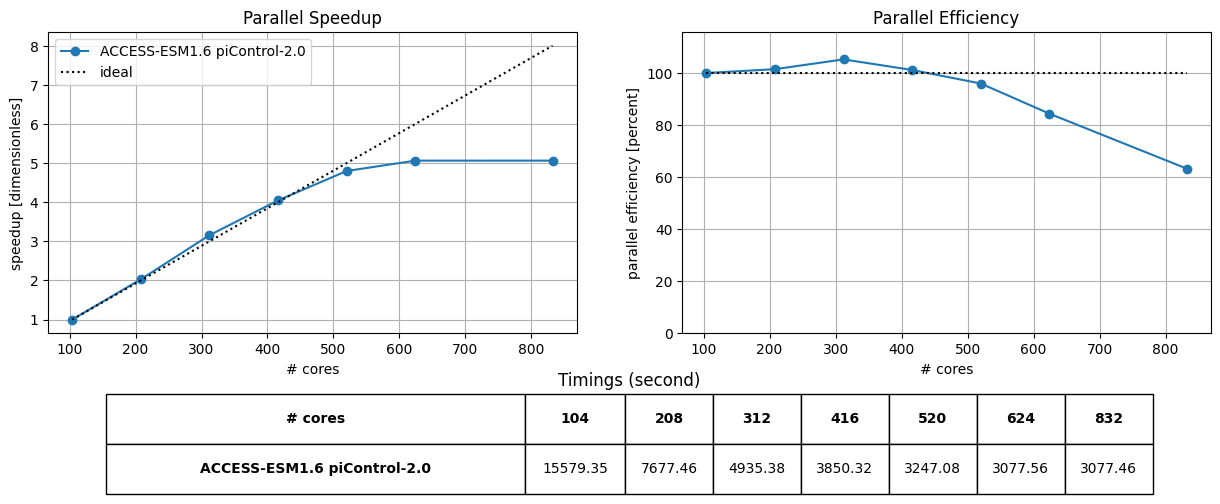

In [8]:
# Plot the parallel speedup and efficiency of the time-stepping regions for this configuration
fig = esm_profiling.plot_scaling_data(
    components=["payu"],
    regions=[
        ["payu_model_run_duration_seconds"],
    ],
    metric=tmax,
    region_relabel_map={
        "payu_model_run_duration_seconds": "ACCESS-ESM1.6 piControl-2.0",
    },
    experiments=best_experiments,
    xlabel="# cores",
)

## Analyis

The above plots show the strong scaling results for the [ACCESS-ESM1.6 piControl v2.0](https://github.com/ACCESS-NRI/access-esm1.6-configs/releases/tag/release-piControl-2.0) configuration. The underlying components are UM7.3 for atmosphere, MOM5 for ocean, CICE5 for the ice model, and OASIS-MCT v5.2. The three components run concurrently over the course of the experiment, with the atmosphere and ice cores responsible for exchanging data (i.e., MPI operations between all three components). The released configuration for ESM1.6 uses 5 nodes on the normalsr queue with Sapphire Rapids CPUs, where each node contains 104 cores.

We have varied the number of nodes between 1 and 8, and for each case, we have tested several options with different partitioning of the total number of available cores between the three components. In the plots above, we have presented the best performing partition for each case. For the two top plots, the x-axis is the total number of cores used in the configuration, and the y-axis is speedup relative to the single node config (left) and computational efficiency relative to the single node config (right). The plot on the left shows that the ESM1.6 model achieves near-ideal scaling up to 5 nodes, and then performance drops off and plateaus for higher node-counts. We observe a similar effect in the computational efficiency as well - the efficiency is above 90% for all node counts up to 5, but then drops off for higher node counts. This is likely caused by the serial fraction of work (Amdahl's law) and the communication overhead between the components. The table shows the raw timings used to compute the parallel speedup and efficiency.

## Summary

- **Setup**: Strong scaling of the ACCESS-ESM1.6 piControl v1.0 configuration (UM7.3 atmosphere + MOM5 ocean + CICE5 sea ice, running concurrently) on Sapphire Rapids, from 1 to 8 nodes. The best-performing core partitioning is shown at each count.
- **Scaling**: Near-ideal scaling up to 5 nodes, with efficiency above 90%. Beyond that, speedup drops off and plateaus.
- **Production**: The released configuration uses 5 nodes, right at the edge of the near-ideal scaling range.
- **Limiting factors**: The drop-off beyond 5 nodes is likely due to the serial fraction of the work (Amdahl's law) combined with communication overhead between components.

# Archive

Archive experiments.

In [9]:
esm_profiling.archive_experiments(exclude_files=[
        "*.nc", 
        "aiihca*",
    ])

Experiment at /g/data/tm70/model_scaling/ACCESS-ESM1.6/piControl-2.0/archive/esm1p6-layout_atm_22x14_mom_18x17_ice_9x1.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-ESM1.6/piControl-2.0/archive/esm1p6-layout_atm_18x12_mom_15x13_ice_4x1.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-ESM1.6/piControl-2.0/archive/esm1p6-layout_atm_18x12_mom_15x13_ice_3x1.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-ESM1.6/piControl-2.0/archive/esm1p6-layout_atm_14x11_mom_14x10_ice_15x1.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-ESM1.6/piControl-2.0/archive/esm1p6-layout_atm_22x19_mom_20x20_ice_6x1.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-ESM1.6/piControl-2.0/archive/esm1p6-layout_atm_20x13_mom_19x13_ice_8x1.tar.gz is already archived. Skipping archivin